# Iris classification

No tuning for this one

In [1]:
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# library-sprecific:
from xgboost import XGBClassifier
import lightgbm as lgb

In [2]:
RANDOM_SEED = 42

#num_boost_round = 16

### LightGBM

In [3]:
params_lgb = {
    "num_iterations": 2,  # == n_estimators
    "max_depth": 2,
    "learning_rate": 1.,
    "objective": "multiclass", #"binary"  # binary log loss classification (or logistic regression)
    "num_class": 3,  # TODO: why we have to set it manually here???
    #"num_boost_round": 16
}
#num_leaves == max_leaves

## Load and prepare data

In [4]:
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    data['data'],
    data['target'],
    test_size=.6,  # make it harder!
    random_state=RANDOM_SEED
)

In [5]:
import pandas as pd

In [6]:
pd.DataFrame({'label': y_train}).value_counts()

label
2        24
1        21
0        15
Name: count, dtype: int64

In [7]:
pd.DataFrame({'label': y_test}).value_counts()

label
0        35
1        29
2        26
Name: count, dtype: int64

### LightGBM

In [8]:
train_data = lgb.Dataset(X_train, label=y_train)

## Train model

### XGBoost

In [9]:
#booster = xgb.train(
#    {
#        'num_parallel_tree': 4,
#        'subsample': 0.5,
#        'num_class': 3
#    },
#    num_boost_round=num_boost_round,
#    dtrain=dtrain
#)
#booster: ``gbtree``, ``gblinear`` or ``dart``

In [10]:
clf_xgb = XGBClassifier(
    n_estimators=2,
    max_depth=2,
    learning_rate=1.,
    objective='binary:logistic',  # why 'binary'???
    #max_leaves
)

In [11]:
clf_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [12]:
preds_xgb = clf_xgb.predict(X_test)

In [13]:
acc_xgb = accuracy_score(y_test, preds_xgb)
print(f"Accuracy: {acc_xgb:.2%}")

Accuracy: 97.78%


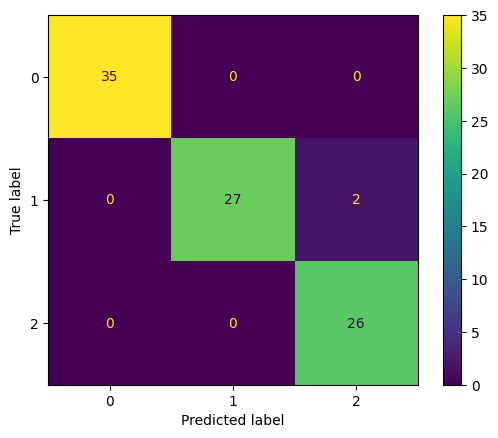

In [14]:
foo = ConfusionMatrixDisplay.from_predictions(y_test, preds_xgb, labels=range(3), cmap='viridis')

### LightGBM

In [15]:
clf_lgb = lgb.train(
    params=params_lgb,
    train_set=train_data,
    #num_boost_round=num_boost_round  # == num_round
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 61
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 4
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.049822
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [16]:
preds_lgb = clf_lgb.predict(X_test)
preds_lgb = np.argmax(preds_lgb, axis=1)

In [17]:
acc_lgb = accuracy_score(y_test, preds_lgb)
print(f"Accuracy: {acc_lgb:.2%}")

Accuracy: 93.33%


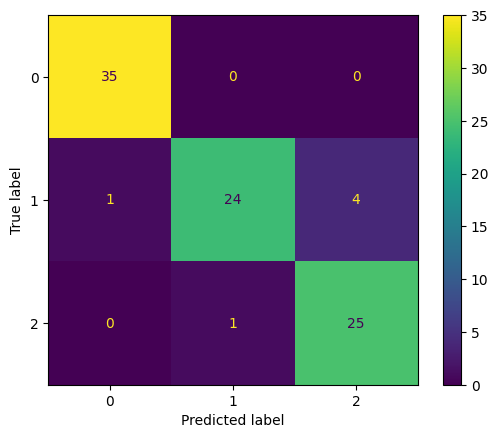

In [18]:
foo = ConfusionMatrixDisplay.from_predictions(y_test, preds_lgb, labels=range(3), cmap='viridis')